# Understanding mAP: a walkthrough

This notebook walks through the study interactively:

1. what the synthetic detectors predict,
2. how Average Precision is built from a precision-recall curve, and what interpolation does,
3. how mAP, oLRP and TIDE judge the same predictions.

Everything uses the `mapstudy` package (`pip install -e ".[notebook]"` from the repository root).

In [1]:
%config InlineBackend.figure_formats = ["jpeg"]

from IPython.display import Markdown
import matplotlib.pyplot as plt
import numpy as np

from mapstudy.average_precision import average_precision, precision_recall_curve
from mapstudy.data import category_names, load_coco_images
from mapstudy.evaluation import evaluate
from mapstudy.reporting import format_results_table
from mapstudy.scenarios import SCENARIOS, generate_detections
from mapstudy.visualization import plot_detections

SEED = 42
images = load_coco_images(300, include_pixels=True)
names = category_names()
print(f"{len(images)} images, {sum(len(i.objects) for i in images)} objects")

300 images, 2160 objects


## 1. What the detectors predict

**Scenario A** shifts every box by 20% of its size along both axes. The IoU is exactly
$r^2 / (2 - r^2) \approx 0.47$ with $r = 0.8$, whatever the size of the object: just under the 0.5 threshold.

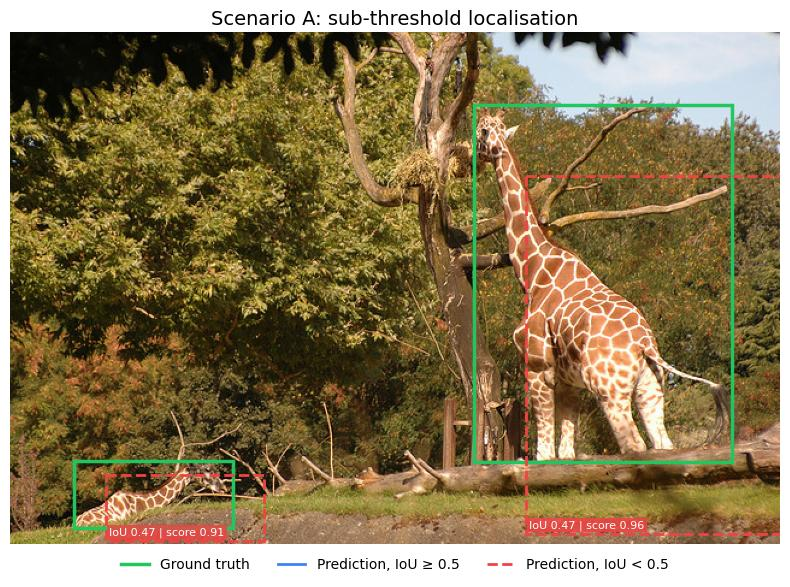

In [2]:
image = images[1]
fig = plot_detections(image, generate_detections([image], "a", SEED), title=SCENARIOS["a"].title)

**Scenario B** keeps one accurate, confident box and adds four low-confidence boxes scattered around each object.

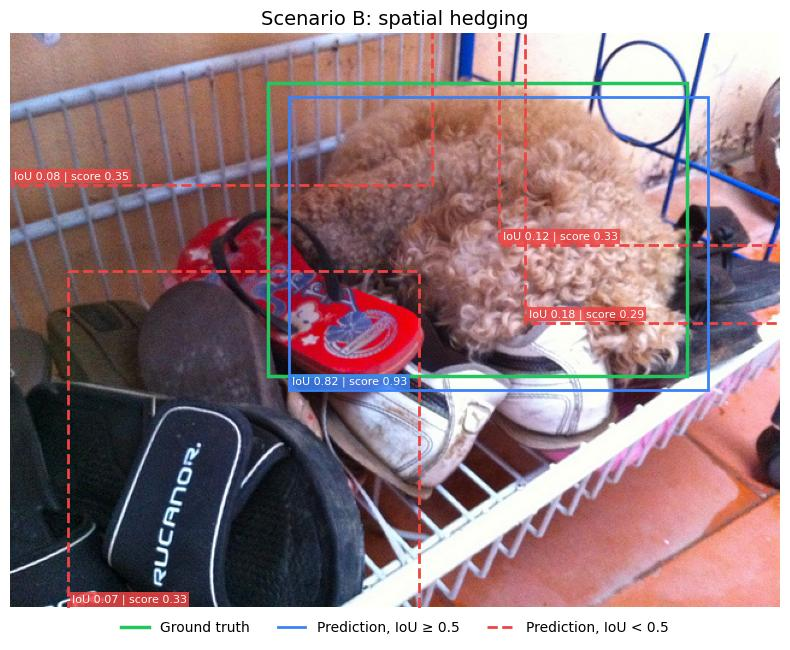

In [3]:
image = images[5]
fig = plot_detections(image, generate_detections([image], "b", SEED), title=SCENARIOS["b"].title)

## 2. From a precision-recall curve to Average Precision

We take the baseline detector (random jitter, uninformative scores) on the most frequent category
and build its precision-recall curve. Detections are ranked by score; each one is a true positive
if it matches a not-yet-matched object with IoU ≥ 0.5.

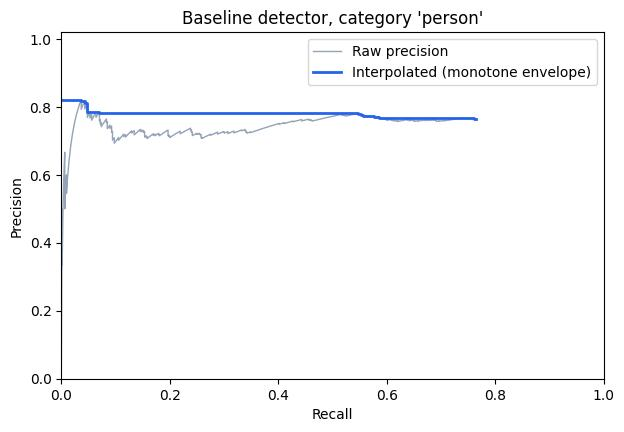

AP (coco) = 0.595
AP ( voc) = 0.597
AP (none) = 0.570


In [4]:
detections = generate_detections(images, "baseline", SEED)
gts = [gt for image in images for gt in image.objects]
category = max(set(g.category_id for g in gts), key=[g.category_id for g in gts].count)

curve = precision_recall_curve(
    [d for d in detections if d.category_id == category],
    [g for g in gts if g.category_id == category],
    iou_threshold=0.5,
)
interpolated = np.maximum.accumulate(curve.precision[::-1])[::-1]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(curve.recall, curve.precision, color="#94a3b8", linewidth=1, label="Raw precision")
ax.plot(curve.recall, interpolated, color="#2563eb", linewidth=2, label="Interpolated (monotone envelope)")
ax.set(xlabel="Recall", ylabel="Precision", title=f"Baseline detector, category '{names[category]}'",
       xlim=(0, 1), ylim=(0, 1.02))
ax.legend()
plt.show()

for scheme in ("coco", "voc", "none"):
    print(f"AP ({scheme:>4}) = {average_precision(curve, scheme):.3f}")

Interpolation replaces each precision value by the best precision achieved at any higher recall.
It removes the saw-tooth dips of the raw curve and therefore always gives an AP at least as high as the raw area.
COCO then samples the envelope at 101 recall levels, while PASCAL VOC integrates it exactly.

## 3. Three metrics, same predictions

In [5]:
reports = [
    evaluate(images, generate_detections(images, name, SEED), scenario=name, seed=SEED)
    for name in SCENARIOS
]
Markdown(format_results_table(reports))

| Metric | Baseline | Scenario A | Scenario B |
| --- | ---: | ---: | ---: |
| mAP@[.50:.95] (pycocotools) | 0.188 | 0.001 | 0.700 |
| mAP@.50 (pycocotools) | 0.660 | 0.004 | 1.000 |
| mAP@.50 (ours, COCO 101-point) | 0.660 | 0.004 | 1.000 |
| mAP@.50 (ours, VOC all-point) | 0.661 | 0.004 | 1.000 |
| mAP@.50 (ours, no interpolation) | 0.635 | 0.003 | 1.000 |
| oLRP ↓ | 0.804 | 0.998 | 0.355 |
| oLRP localisation ↓ | 0.348 | 0.402 | 0.178 |
| oLRP false positive ↓ | 0.200 | 0.833 | 0.000 |
| oLRP false negative ↓ | 0.245 | 0.986 | 0.000 |
| TIDE AP@.50 | 0.660 | 0.004 | 1.000 |
| TIDE dominant error | Loc | Loc | none |
| Detections / objects | 2160 / 2160 | 2160 / 2160 | 10800 / 2160 |

What to read in this table:

- **Scenario A** scores (almost) zero mAP although every box covers its object. The few remaining
  true positives come from predictions that happen to overlap *another* object of the same class.
  TIDE correctly attributes the loss to localisation (`Loc`).
- **Scenario B** gets a perfect mAP@0.50: all hedging boxes rank below every accurate box, so they
  only appear after recall has reached 1 and never lower the curve. TIDE finds no error to fix for
  the same reason. Only oLRP, which picks an optimal score threshold, reports the residual localisation error.
- mAP@[.50:.95] of scenario B is exactly 0.7: the accurate boxes have IoU ≈ 0.82, so they are true positives
  for the 7 thresholds from 0.50 to 0.80 and false positives for the 3 above.